In [1]:
# ============================================================
# 0. IMPORTS & SEED
# ============================================================
import os, time, random, itertools
from glob import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pack_padded_sequence
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

SEED = 9999
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Пути
BASE_DIR   = "/kaggle/input/competitions/dl-lab-4-ocr"
TRAIN_DIR  = os.path.join(BASE_DIR, "train/train")
TEST_DIR   = os.path.join(BASE_DIR, "test/test")
TRAIN_CSV  = os.path.join(BASE_DIR, "train.csv")
TEST_CSV   = os.path.join(BASE_DIR, "test.csv")
SAMPLE_CSV = os.path.join(BASE_DIR, "sample_submission.csv")

# Размеры изображений
IMG_H, IMG_W = 32, 64

# CTC: 0=blank, 1-10 → цифры '0'-'9'
BLANK_IDX  = 0
VOCAB      = ['_'] + [str(d) for d in range(10)]   # len=11
NUM_CLASSES = len(VOCAB)                            # 11
CHAR2IDX   = {c: i for i, c in enumerate(VOCAB)}

print("=" * 60)
print("  OCR Price Recognition  |  STN + CRNN + CTC")
print("=" * 60)
print(f"  Device : {device}")
print(f"  IMG    : {IMG_H}×{IMG_W}  (H×W)")
print(f"  Vocab  : {VOCAB}  ({NUM_CLASSES} classes)")
print("=" * 60)

  OCR Price Recognition  |  STN + CRNN + CTC
  Device : cuda
  IMG    : 32×64  (H×W)
  Vocab  : ['_', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']  (11 classes)


In [2]:
# ============================================================
# 1. LABEL ENCODING
# ============================================================

BLANK_IDX   = 0
VOCAB       = ['_'] + [str(d) for d in range(10)]
# VOCAB[0]='_'(blank), VOCAB[1]='0', VOCAB[2]='1', ..., VOCAB[10]='9'
NUM_CLASSES = len(VOCAB)   # 11
CHAR2IDX    = {c: i for i, c in enumerate(VOCAB)}
# {'_':0, '0':1, '1':2, '2':3, '3':4, '4':5,
#  '5':6, '6':7, '7':8, '8':9, '9':10}

print("VOCAB    :", VOCAB)
print("CHAR2IDX :", CHAR2IDX)


def price_to_seq(price: int) -> list[int]:
    """Число → список индексов символов (без blank).
    109 → ['1','0','9'] → [CHAR2IDX['1'], CHAR2IDX['0'], CHAR2IDX['9']]
        →                  [2, 1, 10]
    """
    return [CHAR2IDX[c] for c in str(price)]


def seq_to_price(seq: list[int]) -> str:
    """Список индексов → строка цены (blank=0 пропускается)."""
    return ''.join(VOCAB[i] for i in seq if i != BLANK_IDX)


def greedy_decode(log_probs: torch.Tensor) -> list[str]:
    """
    log_probs: (T, B, C) → список строк длины B.
    Жадное CTC-декодирование: argmax → убрать повторы → убрать blank.
    """
    indices = log_probs.argmax(dim=2)   # (T, B)
    results = []
    for b in range(indices.size(1)):
        seq = indices[:, b].tolist()
        # убрать повторы соседних
        deduped = [seq[0]] + [seq[i] for i in range(1, len(seq))
                               if seq[i] != seq[i - 1]]
        # убрать blank
        chars = [VOCAB[i] for i in deduped if i != BLANK_IDX]
        results.append(''.join(chars))
    return results


# ── Проверки ────────────────────────────────────────────────
# price_to_seq: цифра '0'→idx 1, '1'→idx 2, ..., '9'→idx 10
assert CHAR2IDX['0'] == 1
assert CHAR2IDX['1'] == 2
assert CHAR2IDX['9'] == 10

assert price_to_seq(109) == [2, 1, 10],  f"got {price_to_seq(109)}"
assert price_to_seq(32)  == [4, 3],      f"got {price_to_seq(32)}"
assert price_to_seq(5)   == [6],         f"got {price_to_seq(5)}"

# seq_to_price — обратное преобразование
assert seq_to_price(price_to_seq(109)) == '109'
assert seq_to_price(price_to_seq(32))  == '32'
assert seq_to_price(price_to_seq(5))   == '5'

print("✓ Label encoding OK")
print(f"  price_to_seq(109) = {price_to_seq(109)}  → '{seq_to_price(price_to_seq(109))}'")
print(f"  price_to_seq(32)  = {price_to_seq(32)}   → '{seq_to_price(price_to_seq(32))}'")
print(f"  price_to_seq(5)   = {price_to_seq(5)}    → '{seq_to_price(price_to_seq(5))}'")

VOCAB    : ['_', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
CHAR2IDX : {'_': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6, '6': 7, '7': 8, '8': 9, '9': 10}
✓ Label encoding OK
  price_to_seq(109) = [2, 1, 10]  → '109'
  price_to_seq(32)  = [4, 3]   → '32'
  price_to_seq(5)   = [6]    → '5'


In [3]:
# ============================================================
# 2. PREPROCESSING
# ============================================================

def preprocess_image(path: str) -> np.ndarray:
    """
    BGR → Gray → EqualizeHist → Resize(128×32).
    Возвращает (H=32, W=128) uint8.
    """
    raw     = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    gray    = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    eq      = cv2.equalizeHist(gray)
    resized = cv2.resize(eq, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)  # cv2: (W, H)
    return resized  # (32, 64) uint8

print("✓ Preprocessing pipeline ready")
print(f"  Steps: BGR → Gray → EqualizeHist → Resize({IMG_H}×{IMG_W})")

✓ Preprocessing pipeline ready
  Steps: BGR → Gray → EqualizeHist → Resize(32×64)


In [4]:
# ============================================================
# 3. AUGMENTATION PIPELINE
# ============================================================

_aug_train = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.01, scale_limit=0.05, rotate_limit=3,
        border_mode=cv2.BORDER_REFLECT_101, p=0.3,
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.08, contrast_limit=0.08, p=1.0),
        A.RandomGamma(gamma_limit=(92, 108), p=1.0),
    ], p=0.3),
    A.GaussNoise(std_range=(0.01, 0.03), p=0.15),
    A.OneOf([
        A.CoarseDropout(
            num_holes_range=(2, 8),
            hole_height_range=(2, 4),
            hole_width_range=(2, 4),
            fill=255, p=1.0,
        ),
        A.PixelDropout(dropout_prob=0.03, per_channel=False, drop_value=255, p=1.0),
    ], p=0.3),
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2(),
])

_aug_val = A.Compose([
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2(),
])

def apply_train_aug(img_gray: np.ndarray) -> torch.Tensor:
    hwc = img_gray[:, :, np.newaxis]
    return _aug_train(image=hwc)["image"]   # (1, H, W) float32

def apply_val_aug(img_gray: np.ndarray) -> torch.Tensor:
    hwc = img_gray[:, :, np.newaxis]
    return _aug_val(image=hwc)["image"]

print("✓ Augmentation pipelines ready")
print("  Train: ShiftScaleRotate | BrightnessContrast/Gamma | GaussNoise | CoarseDropout/PixelDropout | Normalize")
print("  Val  : Normalize only")

✓ Augmentation pipelines ready
  Train: ShiftScaleRotate | BrightnessContrast/Gamma | GaussNoise | CoarseDropout/PixelDropout | Normalize
  Val  : Normalize only


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
# ============================================================
# 4. DATA SPLIT
# ============================================================

train_df = pd.read_csv(TRAIN_CSV, sep='\t' if '\t' in open(TRAIN_CSV).read(1024) else ',')
# Убедиться в правильных столбцах
train_df.columns = train_df.columns.str.strip()
print(f"Train CSV shape : {train_df.shape}")
print(f"Columns         : {list(train_df.columns)}")
print(f"Price range     : {train_df['Price'].min()} – {train_df['Price'].max()}")
print(f"Unique prices   : {train_df['Price'].nunique()}")

# Стратифицированный split (только классы с ≥2 примерами)
class_counts = train_df["Price"].value_counts()
valid_cls    = class_counts[class_counts >= 2].index
df_valid     = train_df[train_df["Price"].isin(valid_cls)]
df_rare      = train_df[~train_df["Price"].isin(valid_cls)]

X_tv, X_val, y_tv, y_val = train_test_split(
    df_valid["Filename"], df_valid["Price"],
    test_size=0.2, random_state=42, stratify=df_valid["Price"],
)

X_train = pd.concat([X_tv, df_rare["Filename"]]).reset_index(drop=True)
y_train = pd.concat([y_tv, df_rare["Price"]]).reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

print(f"\n  Train : {len(X_train):>5}  |  Val : {len(X_val):>4}  |  Rare→train : {len(df_rare)}")

Train CSV shape : (15050, 2)
Columns         : ['Filename', 'Price']
Price range     : 9 – 1939
Unique prices   : 165

  Train : 12040  |  Val : 3010  |  Rare→train : 0


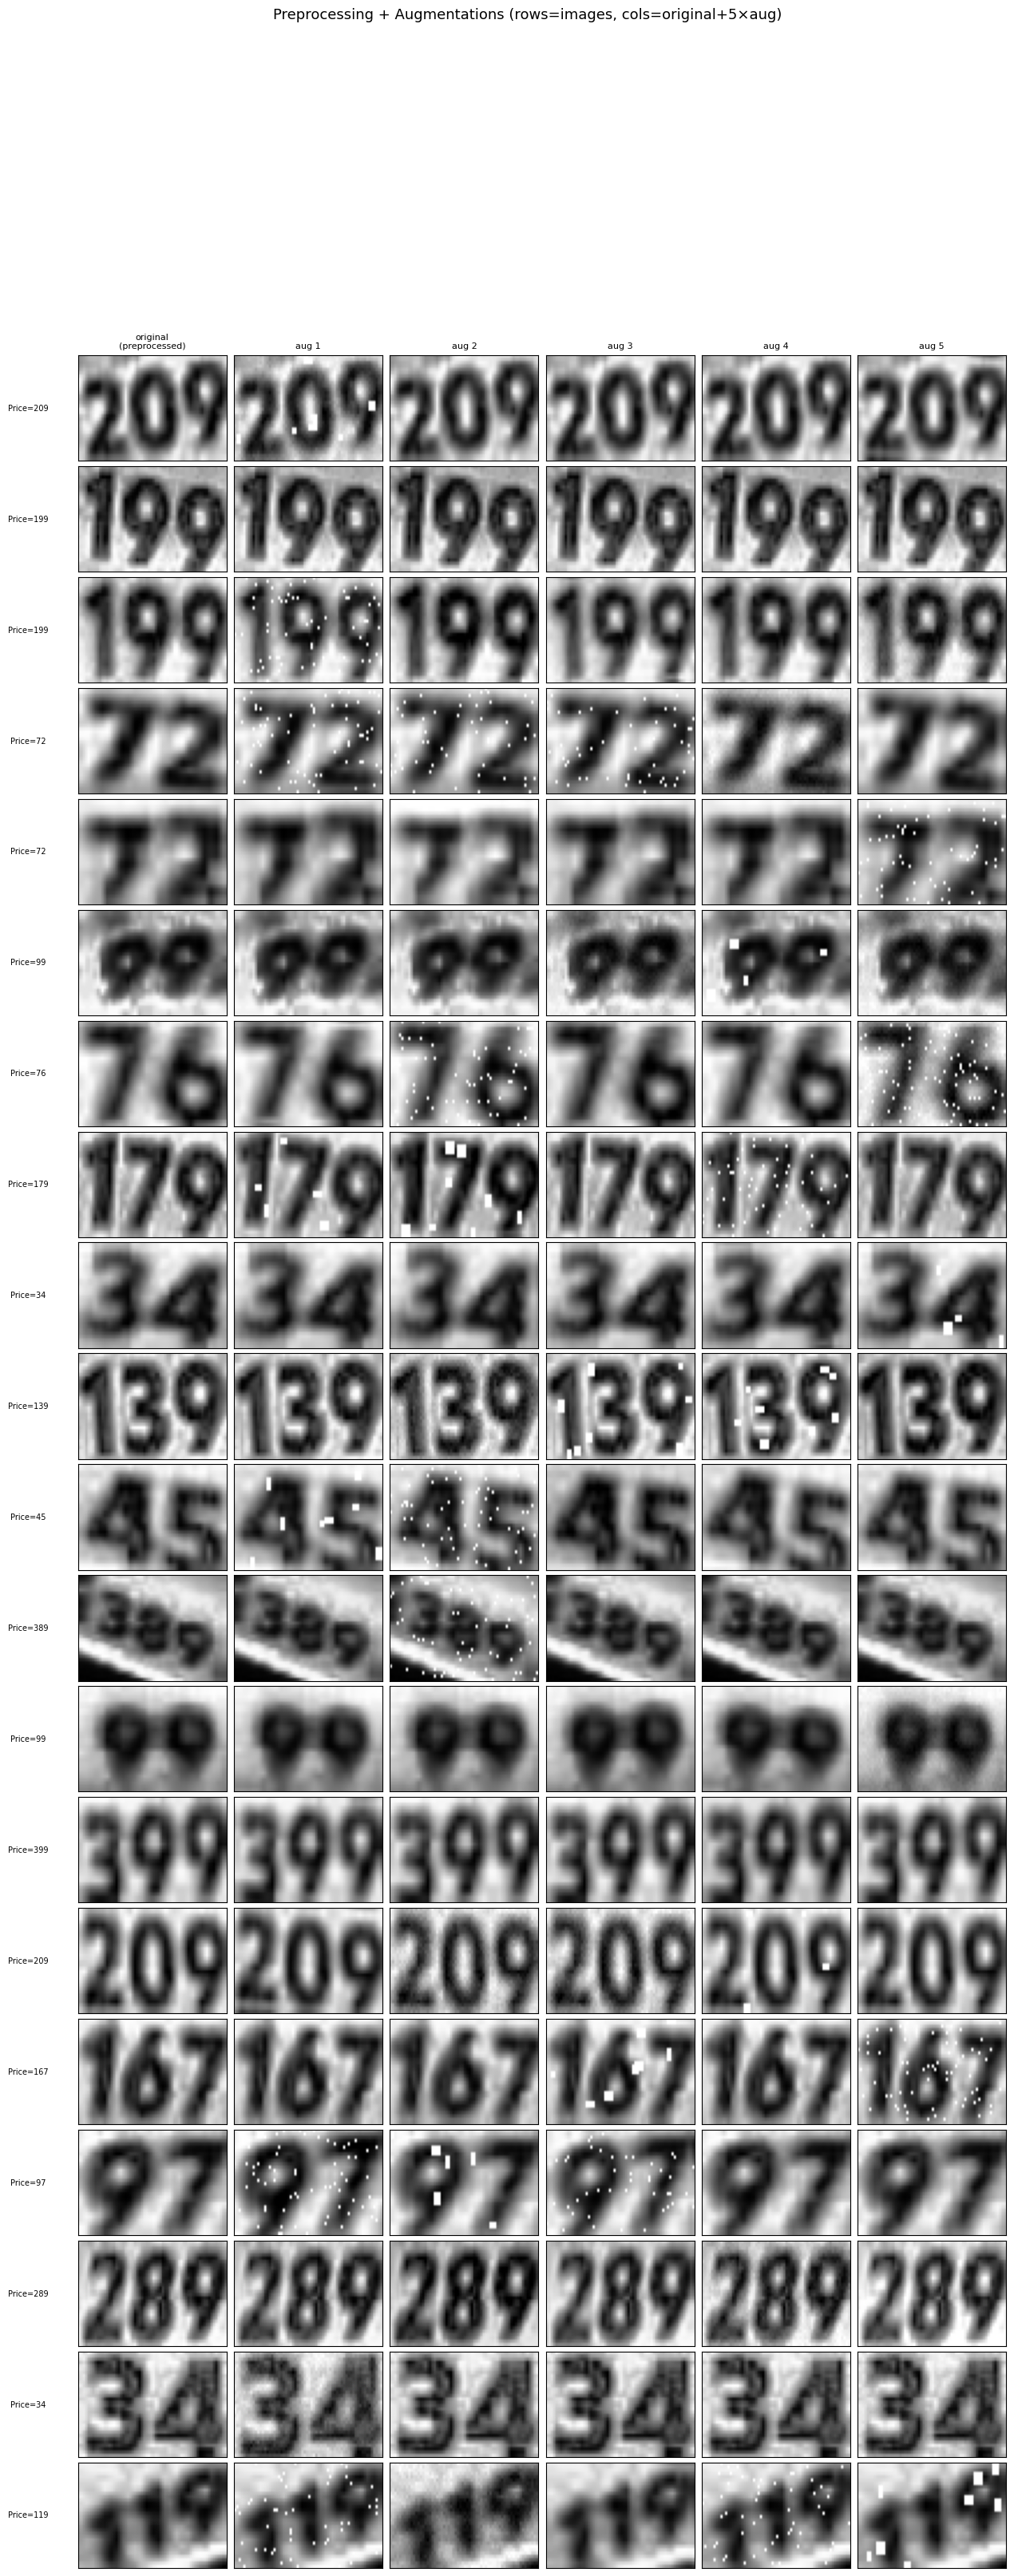

✓ Augmentation visualization saved → augmentation_preview.png


In [6]:
# ============================================================
# 5. VISUALIZATION: 20 images × 5 augmentations
# ============================================================

def visualize_augmentations(n_images=20, n_aug=5):
    sample_fnames = X_train[:n_images].values
    sample_prices = y_train[:n_images].values

    fig, axes = plt.subplots(
        n_images, n_aug + 1,
        figsize=(2.5 * (n_aug + 1), 1.8 * n_images),
        gridspec_kw={'hspace': 0.05, 'wspace': 0.05}
    )
    fig.suptitle("Preprocessing + Augmentations (rows=images, cols=original+5×aug)", 
                 fontsize=13, y=1.001)

    for row, (fname, price) in enumerate(zip(sample_fnames, sample_prices)):
        path    = os.path.join(TRAIN_DIR, fname)
        img_pre = preprocess_image(path)   # (32,128) uint8

        # Оригинал после преобработки
        axes[row, 0].imshow(img_pre, cmap='gray', aspect='auto')
        axes[row, 0].set_ylabel(f"Price={price}", fontsize=7, rotation=0,
                                labelpad=45, va='center')
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        if row == 0:
            axes[row, 0].set_title("original\n(preprocessed)", fontsize=8)

        # 5 аугментаций
        for col in range(1, n_aug + 1):
            aug_t = apply_train_aug(img_pre)          # (1,32,128) float32
            aug_np = aug_t.squeeze(0).numpy()         # (32,128)
            axes[row, col].imshow(aug_np, cmap='gray', vmin=-1, vmax=1, aspect='auto')
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(f"aug {col}", fontsize=8)

    plt.savefig("augmentation_preview.png", bbox_inches='tight', dpi=100)
    plt.show()
    print("✓ Augmentation visualization saved → augmentation_preview.png")

visualize_augmentations()

In [7]:
# ============================================================
# 6. DATASET & DATALOADER
# ============================================================

SMOOTH_ALPHA = 0.5

def _load_all_images(filenames, base_dir: str, desc: str) -> np.ndarray:
    imgs = []
    for fname in tqdm(filenames, desc=desc, ncols=80, leave=False):
        img = preprocess_image(os.path.join(base_dir, fname))
        imgs.append(img)
    return np.stack(imgs, axis=0)   # (N, 32, 128) uint8


class PriceOCRDataset(Dataset):
    def __init__(self, filenames, prices, base_dir, augment_fn, cache=True):
        fnames  = np.array(filenames)
        prices_ = np.array(prices, dtype=np.int32)
        self.filenames  = fnames
        self.prices     = prices_
        self.base_dir   = base_dir
        self.augment_fn = augment_fn
        self.cache      = cache
        if cache:
            self.images = _load_all_images(fnames, base_dir,
                                           f"  Caching {len(fnames)} imgs")
            print(f"    ✓ {len(fnames)} imgs cached  "
                  f"({self.images.nbytes/1024/1024:.1f} MB,  shape={self.images.shape})")

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        img   = self.images[idx] if self.cache else preprocess_image(
                    os.path.join(self.base_dir, self.filenames[idx]))
        img_t = self.augment_fn(img)
        price = int(self.prices[idx])
        seq   = price_to_seq(price)
        return img_t, torch.tensor(seq, dtype=torch.long), price


def collate_fn(batch):
    imgs, seqs, prices = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_len = int(lengths.max())
    padded  = torch.zeros(len(seqs), max_len, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s
    prices  = torch.tensor(prices, dtype=torch.long)
    return imgs, padded, lengths, prices


def make_weighted_sampler(prices):
    freq_map = pd.Series(prices).value_counts().to_dict()
    w = np.array([(1.0/freq_map[p])**SMOOTH_ALPHA for p in prices], dtype=np.float32)
    w /= w.sum()
    return WeightedRandomSampler(w, num_samples=len(w), replacement=True)


# Кешируем один раз глобально
print("Loading & caching datasets...")
_TRAIN_DS = PriceOCRDataset(X_train, y_train, TRAIN_DIR, apply_train_aug, cache=True)
_VAL_DS   = PriceOCRDataset(X_val,   y_val,   TRAIN_DIR, apply_val_aug,   cache=True)
print("✓ Datasets ready\n")


def make_loaders(batch_size: int):
    sampler  = make_weighted_sampler(_TRAIN_DS.prices.tolist())
    train_ld = DataLoader(_TRAIN_DS, batch_size=batch_size, sampler=sampler,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
    val_ld   = DataLoader(_VAL_DS,   batch_size=batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
    return train_ld, val_ld

print("✓ DataLoader builder ready")
print(f"  WeightedSampler smooth_alpha = {SMOOTH_ALPHA}")

Loading & caching datasets...


    ✓ 12040 imgs cached  (23.5 MB,  shape=(12040, 32, 64))


    ✓ 3010 imgs cached  (5.9 MB,  shape=(3010, 32, 64))
✓ Datasets ready

✓ DataLoader builder ready
  WeightedSampler smooth_alpha = 0.5


In [8]:
# ============================================================
# 7. MODEL: STN
# ============================================================

class STN(nn.Module):
    """
    Spatial Transformer Network.
    Вход  : (B, 1, 32, 64)
    Выход : (B, 1, 32, 64)  ← фиксированный out_size совпадает с входом
    Аффинное преобразование (6 параметров).
    """
    def __init__(self):
        super().__init__()

        # ── Локализационная сеть ──────────────────────────────
        # Вход (B, 1, 32, 64):
        # Conv+Pool → (B, 32, 16, 32)
        # Conv+Pool → (B, 64,  8, 16)
        # AdaptiveAvgPool(1,1) → (B, 64, 1, 1)
        self.loc = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, padding=1),  # (B, 32, 32, 64)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # (B, 32, 16, 32)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 16, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # (B, 64,  8, 16)

            nn.AdaptiveAvgPool2d((1, 1)),                 # (B, 64,  1,  1)
        )

        # ── FC: 64 → 32 → 6 ──────────────────────────────────
        self.fc_loc = nn.Sequential(
            nn.Flatten(),           # (B, 64)
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 6),
        )

        # ── Identity-инициализация (критически важно!) ────────
        # Без этого STN "ломает" изображения в начале обучения
        self.fc_loc[-1].weight.data.zero_()
        self.fc_loc[-1].bias.data.copy_(
            torch.tensor([1, 0, 0,
                          0, 1, 0], dtype=torch.float32)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 1, 32, 64)
        returns: (B, 1, 32, 64)
        """
        # Вычисляем параметры аффинного преобразования
        theta_raw = self.fc_loc(self.loc(x))   # (B, 6)
        theta_raw = theta_raw.view(-1, 2, 3)   # (B, 2, 3)

        # ── Мягкое ограничение параметров ────────────────────
        # Масштаб: [0.8, 1.2] через tanh: 0.2*tanh(x)+1.0
        # Сдвиг (sin угла ±15°): tan(15°)≈0.268 через tanh
        scale_x = 0.2  * torch.tanh(theta_raw[:, 0, 0]) + 1.0  # [0.8, 1.2]
        scale_y = 0.2  * torch.tanh(theta_raw[:, 1, 1]) + 1.0  # [0.8, 1.2]
        shear_x = 0.268 * torch.tanh(theta_raw[:, 0, 1])       # [-0.268, 0.268]
        shear_y = 0.268 * torch.tanh(theta_raw[:, 1, 0])       # [-0.268, 0.268]
        tx      = theta_raw[:, 0, 2]                            # трансляция X
        ty      = theta_raw[:, 1, 2]                            # трансляция Y

        # Собираем матрицу (B, 2, 3)
        theta = torch.stack([
            torch.stack([scale_x, shear_x, tx], dim=1),
            torch.stack([shear_y, scale_y, ty], dim=1),
        ], dim=1)  # (B, 2, 3)

        # ── Сэмплирование в фиксированный размер 32×64 ───────
        # out_size = (B, 1, H=32, W=64) — совпадает с входом
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)   # (B, 1, 32, 64)


# ============================================================
# 8. MODEL: CRNN (параметризованная)
# ============================================================

class CRNN(nn.Module):
    """
    CNN Feature Extractor + BiLSTM + FC.
    channels : список из 4 чисел — каналы Conv1..Conv4 backbone.
    hidden   : hidden size BiLSTM.
    dropout  : dropout между слоями BiLSTM.
    """
    def __init__(self, channels: list[int], hidden: int, dropout: float = 0.3,
                 num_classes: int = NUM_CLASSES):
        super().__init__()
        c1, c2, c3, c4 = channels

        self.cnn = nn.Sequential(
            nn.Conv2d(1,  c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
            nn.Conv2d(c3, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            nn.Conv2d(c3, c4, kernel_size=3, padding=1),
            nn.BatchNorm2d(c4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4, 1), stride=(4, 1)),
        )

        # ── BiLSTM с параметризованным dropout ───────────────
        self.rnn = nn.LSTM(
            input_size=c4,
            hidden_size=hidden,
            num_layers=2,
            batch_first=False,
            bidirectional=True,
            dropout=dropout,        # ← параметр, не константа
        )

        self.fc = nn.Linear(hidden * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.cnn(x)           # (B, c4, 1, 32)
        feat = feat.squeeze(2)       # (B, c4, 32)
        feat = feat.permute(2, 0, 1) # (T=32, B, c4)
        out, _ = self.rnn(feat)      # (T=32, B, hidden*2)
        logits = self.fc(out)        # (T=32, B, num_classes)
        return F.log_softmax(logits, dim=2)


# ============================================================
# 9. ПОЛНАЯ МОДЕЛЬ: STN + CRNN
# ============================================================

class STN_CRNN(nn.Module):
    def __init__(self, channels: list[int], hidden: int, dropout: float = 0.3):
        super().__init__()
        self.stn  = STN()
        self.crnn = CRNN(channels, hidden, dropout)   # ← передаём dropout

    def forward(self, x: torch.Tensor, use_stn: bool = True) -> torch.Tensor:
        if use_stn:
            x = self.stn(x)
        return self.crnn(x)


# ── Проверка с зафиксированными параметрами ──────────────────
FIXED_CHANNELS = [64, 128, 256, 512]
FIXED_HIDDEN   = 512
FIXED_LR       = 5e-4

print("=" * 60)
print("  Проверка размерностей STN + CRNN")
print(f"  ЗАФИКСИРОВАНО: lr={FIXED_LR}  ch={FIXED_CHANNELS}  hid={FIXED_HIDDEN}")
print("=" * 60)

  Проверка размерностей STN + CRNN
  ЗАФИКСИРОВАНО: lr=0.0005  ch=[64, 128, 256, 512]  hid=512


In [9]:
# ============================================================
# 10. МЕТРИКИ
# ============================================================

def compute_metrics(log_probs: torch.Tensor, prices: torch.Tensor):
    """
    log_probs : (T, B, C)
    prices    : (B,)  int, настоящие цены
    Возвращает: exact_match (float), cer (float)
    """
    preds = greedy_decode(log_probs)          # список строк
    trues = [str(int(p)) for p in prices]

    exact, total_chars, wrong_chars = 0, 0, 0
    for pred, true in zip(preds, trues):
        exact += int(pred == true)
        # CER: символьная ошибка по выравниванию Левенштейна
        total_chars += len(true)
        wrong_chars += _levenshtein(pred, true)

    n = len(preds)
    cer = wrong_chars / max(total_chars, 1)
    return exact / n, cer


def _levenshtein(s1: str, s2: str) -> int:
    """Расстояние редактирования."""
    if s1 == s2: return 0
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            prev, dp[j] = dp[j], (prev if s1[i-1]==s2[j-1]
                                   else 1 + min(prev, dp[j], dp[j-1]))
    return dp[n]

# Тест
assert _levenshtein("109", "109") == 0
assert _levenshtein("109", "19")  == 1
print("✓ Metrics (ExactMatch, CER, Levenshtein) OK")

✓ Metrics (ExactMatch, CER, Levenshtein) OK


In [10]:
# ============================================================
# 11. ФУНКЦИИ ОБУЧЕНИЯ
# ============================================================

def make_scheduler(optimizer, warmup_epochs, total_epochs, base_lr, min_lr_factor=1e-5):
    """Линейный warmup + CosineAnnealing."""
    def warmup_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return 1.0
    scheduler_w = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)
    scheduler_c = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(total_epochs - warmup_epochs, 1),
        eta_min=base_lr * min_lr_factor,
    )
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, [scheduler_w, scheduler_c], milestones=[warmup_epochs]
    )


ctc_loss_fn = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)


def run_epoch(model, loader, optimizer, use_stn, is_train,
              freeze_crnn=False, freeze_stn=False):
    """Один проход по данным. Возвращает (loss, exact_match, cer)."""
    model.train() if is_train else model.eval()

    # Управление заморозкой
    if freeze_crnn:
        for p in model.crnn.parameters(): p.requires_grad_(False)
    else:
        for p in model.crnn.parameters(): p.requires_grad_(True)
    if freeze_stn:
        for p in model.stn.parameters(): p.requires_grad_(False)
    else:
        for p in model.stn.parameters(): p.requires_grad_(True)

    total_loss, total_em, total_cer, n_batches = 0., 0., 0., 0

    ctx = torch.no_grad() if not is_train else torch.enable_grad()
    with ctx:
        for imgs, seqs, lengths, prices in loader:
            imgs    = imgs.to(device, non_blocking=True)
            seqs    = seqs.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            prices  = prices.to(device, non_blocking=True)

            log_probs = model(imgs, use_stn=use_stn)   # (T, B, C)
            T, B, _   = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

            loss = ctc_loss_fn(log_probs, seqs, input_lengths, lengths)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            em, cer = compute_metrics(log_probs.detach(), prices.cpu())
            total_loss += loss.item()
            total_em   += em
            total_cer  += cer
            n_batches  += 1

    return total_loss/n_batches, total_em/n_batches, total_cer/n_batches


# Хранилище истории для каждой конфигурации
History = dict   # {'train_loss':[], 'val_loss':[], 'train_em':[], ...}

In [11]:
# ============================================================
# 12. ТРЁХЭТАПНОЕ ОБУЧЕНИЕ (для одной конфигурации)
# ============================================================

def train_config(cfg: dict, batch_size: int = 256, verbose: bool = True) -> tuple[STN_CRNN, dict]:
    """
    Обучает STN_CRNN по трём этапам.
    cfg: {
        'channels'     : [...],
        'hidden'       : int,
        'lr'           : float,
        'dropout'      : float,   ← новый ключ
        'weight_decay' : float,   ← новый ключ
    }
    Возвращает (model, history).
    """
    channels     = cfg['channels']
    hidden       = cfg['hidden']
    lr           = cfg['lr']
    dropout      = cfg['dropout']       # ← из cfg
    weight_decay = cfg['weight_decay']  # ← из cfg

    # ── Создание модели и лоадеров ──────────────────────────
    model = STN_CRNN(channels, hidden, dropout).to(device)   # ← передаём dropout
    train_ld, val_ld = make_loaders(batch_size)

    history = defaultdict(list)

    def _epoch_log(stage, ep, total_ep, t_loss, t_em, t_cer,
                   v_loss, v_em, v_cer, elapsed):
        if verbose:
            print(f"  [{stage}] ep {ep:>2}/{total_ep}"
                  f"  │ train  loss={t_loss:.4f}  em={t_em:.3f}  cer={t_cer:.3f}"
                  f"  │  val   loss={v_loss:.4f}  em={v_em:.3f}  cer={v_cer:.3f}"
                  f"  │ {elapsed:.1f}s")

    # ────────────────────────────────────────────────────────
    # ЭТАП 0: Предобучение CRNN без STN (10 эпох)
    # ────────────────────────────────────────────────────────
    STAGE0_EPOCHS = 10
    STAGE0_WARMUP = 3

    if verbose:
        print(f"\n  ┌─ Stage 0: CRNN pre-train (no STN)  ─── {STAGE0_EPOCHS} epochs")

    opt0 = torch.optim.AdamW(
        model.crnn.parameters(), lr=lr, weight_decay=weight_decay   # ← weight_decay
    )
    sch0 = make_scheduler(opt0, STAGE0_WARMUP, STAGE0_EPOCHS, lr)

    for ep in range(1, STAGE0_EPOCHS + 1):
        t0 = time.time()
        tl, tem, tcer = run_epoch(model, train_ld, opt0, use_stn=False,
                                  is_train=True, freeze_stn=True)
        vl, vem, vcer = run_epoch(model, val_ld,   opt0, use_stn=False,
                                  is_train=False,  freeze_stn=True)
        sch0.step()
        elapsed = time.time() - t0
        _epoch_log("S0", ep, STAGE0_EPOCHS, tl, tem, tcer, vl, vem, vcer, elapsed)
        for k, v in [('s0_tl', tl), ('s0_vl', vl), ('s0_tem', tem),
                     ('s0_vem', vem), ('s0_tcer', tcer), ('s0_vcer', vcer)]:
            history[k].append(v)

    # ────────────────────────────────────────────────────────
    # ЭТАП 1: Обучение STN, заморозка CRNN (10 эпох)
    # ────────────────────────────────────────────────────────
    STAGE1_EPOCHS = 10
    STAGE1_WARMUP = 3

    if verbose:
        print(f"\n  ├─ Stage 1: STN train (CRNN frozen)  ── {STAGE1_EPOCHS} epochs")

    opt1 = torch.optim.AdamW(
        model.stn.parameters(), lr=lr, weight_decay=weight_decay    # ← weight_decay
    )
    sch1 = make_scheduler(opt1, STAGE1_WARMUP, STAGE1_EPOCHS, lr)

    for ep in range(1, STAGE1_EPOCHS + 1):
        t0 = time.time()
        tl, tem, tcer = run_epoch(model, train_ld, opt1, use_stn=True,
                                  is_train=True, freeze_crnn=True)
        vl, vem, vcer = run_epoch(model, val_ld,   opt1, use_stn=True,
                                  is_train=False,  freeze_crnn=True)
        sch1.step()
        elapsed = time.time() - t0
        _epoch_log("S1", ep, STAGE1_EPOCHS, tl, tem, tcer, vl, vem, vcer, elapsed)
        for k, v in [('s1_tl', tl), ('s1_vl', vl), ('s1_tem', tem),
                     ('s1_vem', vem), ('s1_tcer', tcer), ('s1_vcer', vcer)]:
            history[k].append(v)

    # ────────────────────────────────────────────────────────
    # ЭТАП 2: Совместное обучение (50 эпох)
    # ────────────────────────────────────────────────────────
    STAGE2_EPOCHS = 20

    if verbose:
        print(f"\n  └─ Stage 2: Joint STN+CRNN fine-tune ─ {STAGE2_EPOCHS} epochs")

    opt2 = torch.optim.AdamW(
        model.parameters(), lr=lr * 0.1, weight_decay=weight_decay  # ← weight_decay
    )
    sch2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2, mode='max', factor=0.2, patience=8, min_lr=lr * 1e-4,
    )
    best_vem, best_state = 0.0, None

    for ep in range(1, STAGE2_EPOCHS + 1):
        t0 = time.time()
        tl, tem, tcer = run_epoch(model, train_ld, opt2, use_stn=True, is_train=True)
        vl, vem, vcer = run_epoch(model, val_ld,   opt2, use_stn=True, is_train=False)
        sch2.step(vem)
        elapsed = time.time() - t0
        _epoch_log("S2", ep, STAGE2_EPOCHS, tl, tem, tcer, vl, vem, vcer, elapsed)
        for k, v in [('s2_tl', tl), ('s2_vl', vl), ('s2_tem', tem),
                     ('s2_vem', vem), ('s2_tcer', tcer), ('s2_vcer', vcer)]:
            history[k].append(v)
        if vem > best_vem:
            best_vem   = vem
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    history['best_val_em'] = best_vem
    if verbose:
        print(f"\n  ✓ Best val ExactMatch = {best_vem:.4f}\n")

    return model, dict(history)

In [12]:
# ============================================================
# 13. GRID SEARCH  —  Dropout × Weight Decay
#     Зафиксировано: lr=5e-4  channels=[64,128,256,512]  hidden=512
# ============================================================

GRID = {
    'dropout':      [0.1, 0.2, 0.3, 0.4, 0.5],
    'weight_decay': [0, 1e-4, 1e-3, 1e-2],
}

# Все комбинации: 5 × 4 = 20
all_configs = [
    {
        'lr':           FIXED_LR,
        'channels':     FIXED_CHANNELS,
        'hidden':       FIXED_HIDDEN,
        'dropout':      do,
        'weight_decay': wd,
    }
    for do, wd in itertools.product(GRID['dropout'], GRID['weight_decay'])
]

print("=" * 60)
print(f"  Grid Search: {len(all_configs)} конфигурации")
print(f"  ЗАФИКСИРОВАНО: lr={FIXED_LR}  ch={FIXED_CHANNELS}  hid={FIXED_HIDDEN}")
print("=" * 60)
print(f"  {'#':<5} {'dropout':<10} {'weight_decay':<15}")
print("  " + "─" * 32)
for i, c in enumerate(all_configs, 1):
    print(f"  [{i:>2}]  dropout={c['dropout']:.1f}   wd={c['weight_decay']:.0e}" if c['weight_decay'] > 0
          else f"  [{i:>2}]  dropout={c['dropout']:.1f}   wd=0")
print("=" * 60)

# Хранилище результатов
gs_results = []

BATCH_SIZE = 256

for cfg_idx, cfg in enumerate(all_configs, 1):
    sep = "─" * 58
    print(f"\n{sep}")
    wd_str = f"{cfg['weight_decay']:.0e}" if cfg['weight_decay'] > 0 else "0"
    print(f"  Config [{cfg_idx:>2}/{len(all_configs)}]  "
          f"dropout={cfg['dropout']:.1f}  weight_decay={wd_str}")
    print(sep)

    model, history = train_config(cfg, batch_size=BATCH_SIZE, verbose=True)

    ckpt_path = f"ckpt_cfg{cfg_idx:02d}_do{cfg['dropout']}_wd{wd_str}.pt"
    torch.save(model.state_dict(), ckpt_path)

    gs_results.append({
        'cfg_idx':     cfg_idx,
        'cfg':         cfg,
        'best_val_em': history['best_val_em'],
        'history':     history,
        'ckpt_path':   ckpt_path,
    })

    print(f"  → Saved: {ckpt_path}  |  best_val_em={history['best_val_em']:.4f}")

gs_results.sort(key=lambda x: x['best_val_em'], reverse=True)

print("\n" + "=" * 60)
print("  GRID SEARCH RESULTS (по убыванию val ExactMatch)")
print("=" * 60)
print(f"  {'Rank':<5} {'dropout':<10} {'weight_decay':<15} {'val_EM':<10}")
print("  " + "─" * 42)
for rank, r in enumerate(gs_results, 1):
    c = r['cfg']
    wd_str = f"{c['weight_decay']:.0e}" if c['weight_decay'] > 0 else "0"
    print(f"  {rank:<5} {c['dropout']:<10.1f} {wd_str:<15} {r['best_val_em']:<10.4f}")
print("=" * 60)

  Grid Search: 20 конфигурации
  ЗАФИКСИРОВАНО: lr=0.0005  ch=[64, 128, 256, 512]  hid=512
  #     dropout    weight_decay   
  ────────────────────────────────
  [ 1]  dropout=0.1   wd=0
  [ 2]  dropout=0.1   wd=1e-04
  [ 3]  dropout=0.1   wd=1e-03
  [ 4]  dropout=0.1   wd=1e-02
  [ 5]  dropout=0.2   wd=0
  [ 6]  dropout=0.2   wd=1e-04
  [ 7]  dropout=0.2   wd=1e-03
  [ 8]  dropout=0.2   wd=1e-02
  [ 9]  dropout=0.3   wd=0
  [10]  dropout=0.3   wd=1e-04
  [11]  dropout=0.3   wd=1e-03
  [12]  dropout=0.3   wd=1e-02
  [13]  dropout=0.4   wd=0
  [14]  dropout=0.4   wd=1e-04
  [15]  dropout=0.4   wd=1e-03
  [16]  dropout=0.4   wd=1e-02
  [17]  dropout=0.5   wd=0
  [18]  dropout=0.5   wd=1e-04
  [19]  dropout=0.5   wd=1e-03
  [20]  dropout=0.5   wd=1e-02

──────────────────────────────────────────────────────────
  Config [ 1/20]  dropout=0.1  weight_decay=0
──────────────────────────────────────────────────────────

  ┌─ Stage 0: CRNN pre-train (no STN)  ─── 10 epochs
  [S0] ep  1/10  │ t

In [13]:
# ============================================================
# 14. АНАЛИЗ ЛУЧШЕЙ КОНФИГУРАЦИИ
# ============================================================

best      = gs_results[0]
best_cfg  = best['cfg']
best_hist = best['history']

wd_str = f"{best_cfg['weight_decay']:.0e}" if best_cfg['weight_decay'] > 0 else "0"

print("\n" + "=" * 60)
print("  ЛУЧШАЯ КОНФИГУРАЦИЯ")
print("=" * 60)
print(f"  LR           : {best_cfg['lr']}          (зафиксировано)")
print(f"  Channels     : {best_cfg['channels']}  (зафиксировано)")
print(f"  Hidden       : {best_cfg['hidden']}         (зафиксировано)")
print(f"  Dropout      : {best_cfg['dropout']}         ← найдено в GS")
print(f"  Weight Decay : {wd_str}      ← найдено в GS")
print(f"  val EM       : {best['best_val_em']:.4f}")
print("=" * 60)

best_model = STN_CRNN(
    best_cfg['channels'],
    best_cfg['hidden'],
    best_cfg['dropout'],       # ← передаём найденный dropout
).to(device)
best_model.load_state_dict(torch.load(best['ckpt_path'], map_location=device))
best_model.eval()
print(f"  ✓ Best model loaded from {best['ckpt_path']}")

total_params = sum(p.numel() for p in best_model.parameters())
stn_params   = sum(p.numel() for p in best_model.stn.parameters())
crnn_params  = sum(p.numel() for p in best_model.crnn.parameters())
print(f"\n  Параметры модели:")
print(f"    STN  : {stn_params:>10,}")
print(f"    CRNN : {crnn_params:>10,}")
print(f"    Total: {total_params:>10,}")


  ЛУЧШАЯ КОНФИГУРАЦИЯ
  LR           : 0.0005          (зафиксировано)
  Channels     : [64, 128, 256, 512]  (зафиксировано)
  Hidden       : 512         (зафиксировано)
  Dropout      : 0.2         ← найдено в GS
  Weight Decay : 1e-03      ← найдено в GS
  val EM       : 0.9872
  ✓ Best model loaded from ckpt_cfg07_do0.2_wd1e-03.pt

  Параметры модели:
    STN  :     21,286
    CRNN : 12,655,755
    Total: 12,677,041


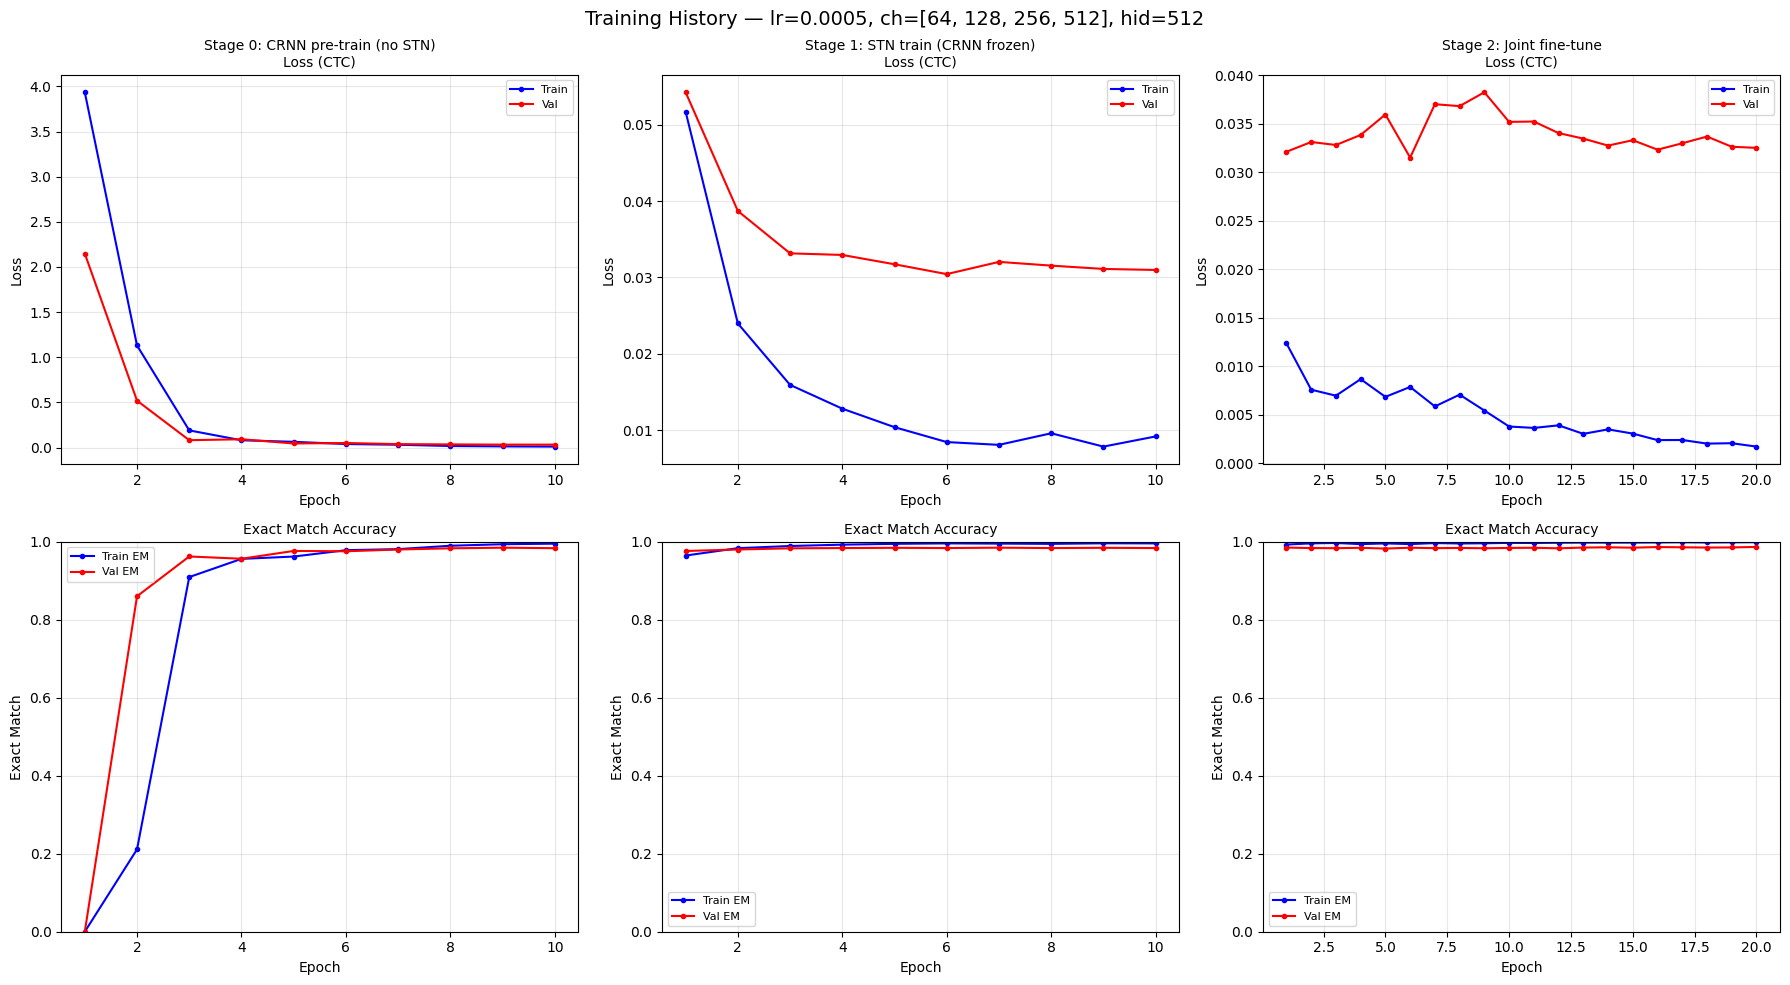

✓ Saved → training_history.png


In [14]:
# ============================================================
# 15. ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ
# ============================================================

def plot_training_history(history: dict, title: str = "Best Config"):
    """Графики loss и ExactMatch по всем трём этапам."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Training History — {title}", fontsize=14)

    stages = [
        ('s0', 'Stage 0: CRNN pre-train (no STN)'),
        ('s1', 'Stage 1: STN train (CRNN frozen)'),
        ('s2', 'Stage 2: Joint fine-tune'),
    ]

    for col, (prefix, stage_name) in enumerate(stages):
        tl_key  = f'{prefix}_tl'
        vl_key  = f'{prefix}_vl'
        tem_key = f'{prefix}_tem'
        vem_key = f'{prefix}_vem'

        if tl_key not in history:
            continue

        tl   = history[tl_key]
        vl   = history[vl_key]
        tem  = history[tem_key]
        vem  = history[vem_key]
        eps  = range(1, len(tl) + 1)

        # Loss
        ax = axes[0, col]
        ax.plot(eps, tl, 'b-o', ms=3, label='Train')
        ax.plot(eps, vl, 'r-o', ms=3, label='Val')
        ax.set_title(f"{stage_name}\nLoss (CTC)", fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # ExactMatch
        ax = axes[1, col]
        ax.plot(eps, tem, 'b-o', ms=3, label='Train EM')
        ax.plot(eps, vem, 'r-o', ms=3, label='Val EM')
        ax.set_title("Exact Match Accuracy", fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Exact Match")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=100, bbox_inches='tight')
    plt.show()
    print("✓ Saved → training_history.png")


plot_training_history(best_hist,
    title=f"lr={best_cfg['lr']}, ch={best_cfg['channels']}, hid={best_cfg['hidden']}")

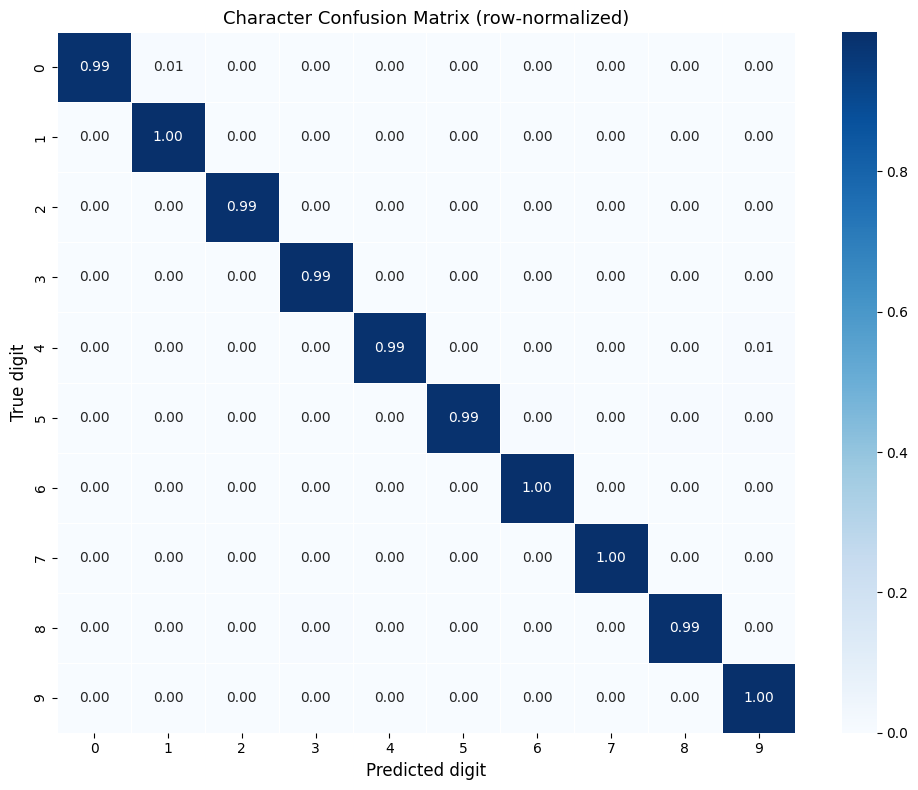

✓ Saved → confusion_matrix.png

  Топ-10 цифровых ошибок (true → pred : count):
    9 → 1 : 3
    9 → 2 : 2
    8 → 3 : 2
    4 → 9 : 2
    3 → 5 : 2
    2 → 7 : 2
    2 → 4 : 2
    1 → 4 : 2
    0 → 1 : 2
    9 → 8 : 1


In [15]:
# ============================================================
# 16. МАТРИЦА СОПРЯЖЁННОСТИ ЦИФР (Character Confusion Matrix)
# ============================================================

def digit_confusion_matrix(model, loader):
    """
    Собирает попарные ошибки на уровне цифр.
    Выравнивание через min(len(pred), len(true)) — быстро и достаточно.
    """
    conf = np.zeros((10, 10), dtype=np.int64)   # true_digit × pred_digit

    model.eval()
    with torch.no_grad():
        for imgs, seqs, lengths, prices in tqdm(loader, desc="Confusion", leave=False):
            imgs   = imgs.to(device, non_blocking=True)
            lp     = model(imgs, use_stn=True)
            preds  = greedy_decode(lp.detach())
            trues  = [str(int(p)) for p in prices]

            for pred, true in zip(preds, trues):
                min_len = min(len(pred), len(true))
                for i in range(min_len):
                    if pred[i].isdigit() and true[i].isdigit():
                        t_d = int(true[i])
                        p_d = int(pred[i])
                        conf[t_d, p_d] += 1

    return conf


_, val_ld_eval = make_loaders(batch_size=256)
conf_matrix = digit_confusion_matrix(best_model, val_ld_eval)

fig, ax = plt.subplots(figsize=(10, 8))
norm_conf = conf_matrix.astype(float)
row_sums  = norm_conf.sum(axis=1, keepdims=True)
norm_conf = np.divide(norm_conf, row_sums, where=row_sums > 0)

sns.heatmap(norm_conf, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=list(range(10)), yticklabels=list(range(10)),
            ax=ax, linewidths=0.5)
ax.set_xlabel("Predicted digit", fontsize=12)
ax.set_ylabel("True digit",      fontsize=12)
ax.set_title("Character Confusion Matrix (row-normalized)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved → confusion_matrix.png")

# Топ-5 ошибок
errors = []
for i in range(10):
    for j in range(10):
        if i != j and conf_matrix[i, j] > 0:
            errors.append((conf_matrix[i, j], i, j))
errors.sort(reverse=True)
print("\n  Топ-10 цифровых ошибок (true → pred : count):")
for cnt, t, p in errors[:10]:
    print(f"    {t} → {p} : {cnt}")

In [16]:
# ============================================================
# 17. GRID SEARCH — СВОДНЫЙ ГРАФИК
#     Dropout × WeightDecay → тепловая карта val ExactMatch
# ============================================================

def plot_gs_summary(gs_results):
    dropouts      = sorted(set(r['cfg']['dropout']      for r in gs_results))
    weight_decays = sorted(set(r['cfg']['weight_decay'] for r in gs_results))

    # Матрица результатов: строки=dropout, столбцы=weight_decay
    matrix = np.zeros((len(dropouts), len(weight_decays)))
    for r in gs_results:
        i = dropouts.index(r['cfg']['dropout'])
        j = weight_decays.index(r['cfg']['weight_decay'])
        matrix[i, j] = r['best_val_em']

    wd_labels = [f"{wd:.0e}" if wd > 0 else "0" for wd in weight_decays]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f"Grid Search: Dropout × Weight Decay\n"
        f"(зафиксировано: lr={FIXED_LR}  ch={FIXED_CHANNELS}  hid={FIXED_HIDDEN})",
        fontsize=12, fontweight='bold'
    )

    # ── Тепловая карта ────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=matrix.min(), vmax=matrix.max(),
                   aspect='auto')
    ax.set_xticks(range(len(weight_decays)))
    ax.set_xticklabels(wd_labels, fontsize=9)
    ax.set_yticks(range(len(dropouts)))
    ax.set_yticklabels([f"{d:.1f}" for d in dropouts], fontsize=9)
    ax.set_xlabel("Weight Decay", fontsize=11)
    ax.set_ylabel("Dropout",      fontsize=11)
    ax.set_title("Val Exact Match (тепловая карта)", fontsize=10)
    plt.colorbar(im, ax=ax)

    # Аннотации значений в ячейках
    for i in range(len(dropouts)):
        for j in range(len(weight_decays)):
            ax.text(j, i, f"{matrix[i, j]:.4f}",
                    ha='center', va='center', fontsize=7.5,
                    color='black' if matrix[i, j] > matrix.mean() else 'white')

    # Выделяем лучшую ячейку
    best_idx = np.unravel_index(matrix.argmax(), matrix.shape)
    ax.add_patch(plt.Rectangle(
        (best_idx[1] - 0.5, best_idx[0] - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3
    ))

    # ── Бар-чарт всех конфигураций (отсортировано) ────────
    ax2 = axes[1]
    scores = [r['best_val_em'] for r in gs_results]   # уже отсортировано
    labels = [
        f"do={r['cfg']['dropout']:.1f}\nwd={'0' if r['cfg']['weight_decay']==0 else f"{r['cfg']['weight_decay']:.0e}"}"
        for r in gs_results
    ]
    colors = ['#F44336'] + ['#2196F3'] * (len(scores) - 1)   # лучший — красный
    bars = ax2.bar(range(len(scores)), scores, color=colors,
                   edgecolor='white', width=0.7)
    ax2.set_xticks(range(len(scores)))
    ax2.set_xticklabels(labels, fontsize=6.5, rotation=0)
    ax2.set_ylabel("Val Exact Match")
    ax2.set_title("Все конфигурации (красный = лучшая)", fontsize=10)
    ax2.set_ylim(max(0, min(scores) - 0.02), min(1.0, max(scores) + 0.02))
    ax2.axhline(scores[0], color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, score in zip(bars, scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{score:.4f}", ha='center', va='bottom', fontsize=6)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig("gs_summary_dropout_wd.png", dpi=100, bbox_inches='tight')
    plt.show()
    print("✓ Saved → gs_summary_dropout_wd.png")

plot_gs_summary(gs_results)

SyntaxError: unexpected character after line continuation character (3840147869.py, line 57)

In [ ]:
# ============================================================
# 19. ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================================

wd_str = f"{best_cfg['weight_decay']:.0e}" if best_cfg['weight_decay'] > 0 else "0"

print("\n" + "═" * 60)
print("  ФИНАЛЬНЫЙ ОТЧЁТ — Grid Search: Dropout × Weight Decay")
print("═" * 60)
print(f"  Зафиксированные параметры:")
print(f"    Learning Rate : {FIXED_LR}")
print(f"    CNN Channels  : {FIXED_CHANNELS}")
print(f"    LSTM Hidden   : {FIXED_HIDDEN}")
print()
print(f"  Найденные параметры (лучшая конфигурация #{best['cfg_idx']}):")
print(f"    Dropout       : {best_cfg['dropout']}")
print(f"    Weight Decay  : {wd_str}")
print(f"    Val EM        : {best['best_val_em']:.4f}")
print()
print(f"  Параметры модели:")
print(f"    STN   : {stn_params:,}")
print(f"    CRNN  : {crnn_params:,}")
print(f"    Total : {total_params:,}")
print("═" * 60)